<a href="https://colab.research.google.com/github/AdityaMitra5102/ML-TImeSeries/blob/main/ssh_detector.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SSH Brute Force Detector
**Dataset:** `mdwiraputradananjaya/ssh-anomaly-dataset`  
**Goal:** Binary classification — `brute_force` vs `normal`  
**Models:** LightGBM vs Isolation Forest  
**Pipeline:** Per-IP sliding window feature engineering → train → compare → export detector

## 0. Install & Imports

In [34]:
# !pip install lightgbm kagglehub scikit-learn pandas numpy matplotlib seaborn

import kagglehub
import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import random
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve,
    average_precision_score, f1_score
)
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

SEED = random.randint(0,1024)
np.random.seed(SEED)
print('All imports OK')

All imports OK


## 1. Load Data

In [35]:
path = kagglehub.dataset_download('mdwiraputradananjaya/ssh-anomaly-dataset')
csv_files = glob.glob(os.path.join(path, '**/*.csv'), recursive=True)
print('Found files:', csv_files)

df = pd.concat([pd.read_csv(f) for f in csv_files], ignore_index=True)
print(f'Shape: {df.shape}')
df.head(3)

Using Colab cache for faster access to the 'ssh-anomaly-dataset' dataset.
Found files: ['/kaggle/input/ssh-anomaly-dataset/ssh_anomaly_dataset.csv']
Shape: (41825, 7)


,timestamp,source_ip,username,event_type,status,label,detail
0,2025-06-15 09:00:00.000000,192.168.0.46,john_doe,Accepted password,success,normal,NaN
1,2025-06-15 09:00:01.673608,192.168.0.46,john_doe,Command executed,pwd,normal,NaN
2,2025-06-15 09:01:05.018929,192.168.0.37,analyst_user,Accepted password,success,normal,NaN


In [36]:
print(df['label'].value_counts())
print('\nDtypes:')
print(df.dtypes)
print('\nNull counts:')
print(df.isnull().sum())

label
brute_force                     37749
normal                           3707
brute_force_connection_issue      367
config_anomaly                      2
Name: count, dtype: int64

Dtypes:
timestamp     object
source_ip     object
username      object
event_type    object
status        object
label         object
detail        object
dtype: object

Null counts:
timestamp         0
source_ip         0
username          0
event_type        0
status            0
label             0
detail        41823
dtype: int64


## 2. Preprocessing

In [37]:
# Parse timestamp
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values('timestamp').reset_index(drop=True)

# Binary label: 1 = brute_force (any variant), 0 = normal
df['label_bin'] = df['label'].apply(
    lambda x: 0 if str(x).strip().lower() == 'normal' else 1
)

print('Binary label distribution:')
print(df['label_bin'].value_counts())
print(f'Imbalance ratio: {df["label_bin"].value_counts()[1] / df["label_bin"].value_counts()[0]:.2f}x')

Binary label distribution:
label_bin
1    38118
0     3707
Name: count, dtype: int64
Imbalance ratio: 10.28x


## 3. Per-IP Sliding Window Feature Engineering

In [38]:
WINDOW_SIZES = [30, 60, 300]  # seconds: 30s, 1min, 5min

def compute_ip_features(df, window_sec=60):
    """
    For each log line, compute rolling features over the past `window_sec`
    seconds FOR THAT SOURCE IP.
    Returns a feature DataFrame aligned to df's index.
    """
    df = df.copy()
    df['ts_epoch'] = df['timestamp'].astype(np.int64) / 1e9
    df['is_failed'] = (df['status'].str.lower() != 'success').astype(int)
    df['is_success'] = (df['status'].str.lower() == 'success').astype(int)

    records = []

    for ip, grp in df.groupby('source_ip'):
        grp = grp.sort_values('ts_epoch').reset_index()
        orig_idx = grp['index'].values
        ts = grp['ts_epoch'].values
        failed = grp['is_failed'].values
        success = grp['is_success'].values
        usernames = grp['username'].values

        for i in range(len(grp)):
            t_now = ts[i]
            mask = (ts >= t_now - window_sec) & (ts <= t_now)
            window = grp[mask]

            n_attempts = mask.sum()
            n_failed = failed[mask].sum()
            n_success = success[mask].sum()
            fail_ratio = n_failed / n_attempts if n_attempts > 0 else 0
            unique_users = len(set(usernames[mask]))

            # Inter-arrival times within window
            ts_window = ts[mask]
            if len(ts_window) > 1:
                iats = np.diff(np.sort(ts_window))
                iat_mean = iats.mean()
                iat_std = iats.std()
                iat_min = iats.min()
                iat_cv = iat_std / iat_mean if iat_mean > 0 else 0  # coefficient of variation
            else:
                iat_mean = iat_std = iat_min = iat_cv = 0

            # Attempt rate (per second)
            attempt_rate = n_attempts / window_sec

            # Event type counts
            ev = window['event_type'].str.lower()
            n_accepted = ev.str.contains('accept').sum()
            n_failed_pw = ev.str.contains('fail').sum()
            n_invalid = ev.str.contains('invalid').sum()

            records.append({
                'orig_idx': orig_idx[i],
                f'w{window_sec}_n_attempts': n_attempts,
                f'w{window_sec}_attempt_rate': attempt_rate,
                f'w{window_sec}_fail_ratio': fail_ratio,
                f'w{window_sec}_unique_users': unique_users,
                f'w{window_sec}_iat_mean': iat_mean,
                f'w{window_sec}_iat_std': iat_std,
                f'w{window_sec}_iat_min': iat_min,
                f'w{window_sec}_iat_cv': iat_cv,
                f'w{window_sec}_n_accepted': n_accepted,
                f'w{window_sec}_n_failed_pw': n_failed_pw,
                f'w{window_sec}_n_invalid': n_invalid,
            })

    feat_df = pd.DataFrame(records).set_index('orig_idx').sort_index()
    return feat_df

print('Computing features for window sizes:', WINDOW_SIZES)
print('This may take a minute...')

Computing features for window sizes: [30, 60, 300]
This may take a minute...


In [39]:
feat_frames = []
for w in WINDOW_SIZES:
    print(f'  Window {w}s...')
    feat_frames.append(compute_ip_features(df, window_sec=w))

features = pd.concat(feat_frames, axis=1)
features = features.loc[~features.index.duplicated(keep='first')]

# Align with main df
df_feat = df.join(features, how='left')

# Drop rows we can't compute features for
df_feat = df_feat.dropna(subset=features.columns.tolist())

print(f'Feature matrix shape: {features.shape}')
features.head(3)

  Window 30s...
  Window 60s...
  Window 300s...
Feature matrix shape: (41825, 33)


,w30_n_attempts,w30_attempt_rate,w30_fail_ratio,w30_unique_users,w30_iat_mean,w30_iat_std,w30_iat_min,w30_iat_cv,w30_n_accepted,w30_n_failed_pw,w30_n_invalid,w60_n_attempts,w60_attempt_rate,w60_fail_ratio,w60_unique_users,w60_iat_mean,w60_iat_std,w60_iat_min,w60_iat_cv,w60_n_accepted,w60_n_failed_pw,w60_n_invalid,w300_n_attempts,w300_attempt_rate,w300_fail_ratio,w300_unique_users,w300_iat_mean,w300_iat_std,w300_iat_min,w300_iat_cv,w300_n_accepted,w300_n_failed_pw,w300_n_invalid
orig_idx,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,1,0.033333,0.0,1,0.000000,0.0,0.000000,0.0,1,0,0,1,0.016667,0.0,1,0.000000,0.0,0.000000,0.0,1,0,0,1,0.003333,0.0,1,0.000000,0.0,0.000000,0.0,1,0,0
1,2,0.066667,0.5,1,1.673608,0.0,1.673608,0.0,1,0,0,2,0.033333,0.5,1,1.673608,0.0,1.673608,0.0,1,0,0,2,0.006667,0.5,1,1.673608,0.0,1.673608,0.0,1,0,0
2,1,0.033333,0.0,1,0.000000,0.0,0.000000,0.0,1,0,0,1,0.016667,0.0,1,0.000000,0.0,0.000000,0.0,1,0,0,1,0.003333,0.0,1,0.000000,0.0,0.000000,0.0,1,0,0


## 4. Exploratory Analysis of Features

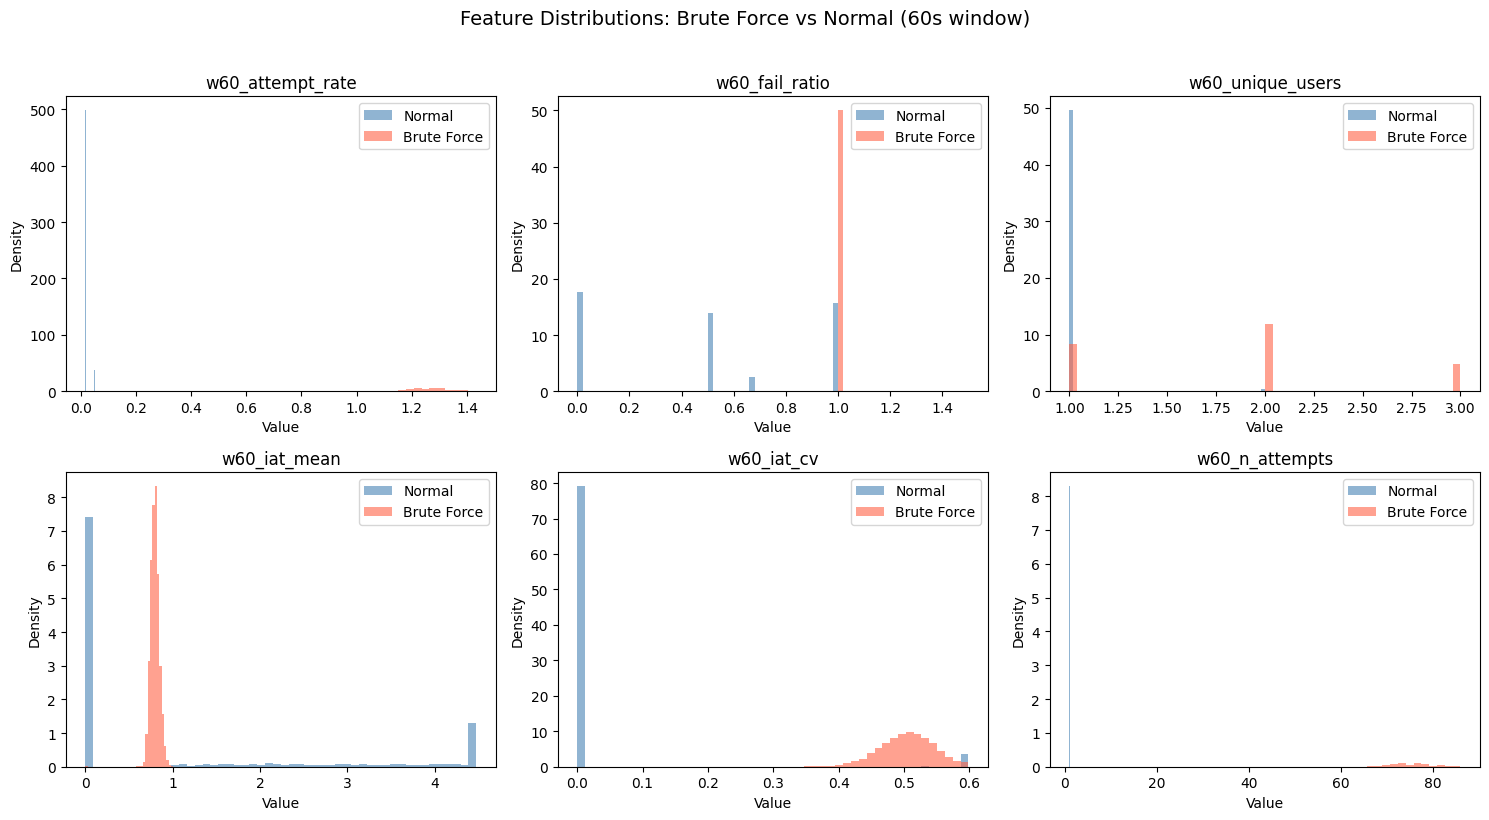

In [40]:
feat_cols = features.columns.tolist()

# Compare feature distributions by label
key_feats = [
    'w60_attempt_rate', 'w60_fail_ratio', 'w60_unique_users',
    'w60_iat_mean', 'w60_iat_cv', 'w60_n_attempts'
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feat in enumerate(key_feats):
    for label, color, name in [(0, 'steelblue', 'Normal'), (1, 'tomato', 'Brute Force')]:
        vals = df_feat[df_feat['label_bin'] == label][feat].clip(upper=df_feat[feat].quantile(0.99))
        axes[i].hist(vals, bins=50, alpha=0.6, color=color, label=name, density=True)
    axes[i].set_title(feat)
    axes[i].legend()
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Density')

plt.suptitle('Feature Distributions: Brute Force vs Normal (60s window)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 5. Train/Test Split (time-based)

In [41]:
# Time-based split — critical for time series, never random split
split_idx = int(len(df_feat) * 0.8)
train_df = df_feat.iloc[:split_idx]
test_df  = df_feat.iloc[split_idx:]

X_train = train_df[feat_cols].values
y_train = train_df['label_bin'].values
X_test  = test_df[feat_cols].values
y_test  = test_df['label_bin'].values

print(f'Train: {X_train.shape}, positives: {y_train.sum()} ({y_train.mean()*100:.1f}%)')
print(f'Test:  {X_test.shape},  positives: {y_test.sum()} ({y_test.mean()*100:.1f}%)')

# Scale for Isolation Forest
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

Train: (33460, 33), positives: 30648 (91.6%)
Test:  (8365, 33),  positives: 7470 (89.3%)


## 6. Model A — Isolation Forest (Unsupervised Baseline)

In [42]:
# Train only on normal traffic to model 'normal' behavior
X_train_normal = X_train_sc[y_train == 0]

iso = IsolationForest(
    n_estimators=200,
    contamination=0.05,  # expected fraction of anomalies
    random_state=SEED,
    n_jobs=-1
)
iso.fit(X_train_normal)

# Score: higher = more anomalous (we flip the sign)
iso_scores_test = -iso.score_samples(X_test_sc)  # anomaly score
iso_pred_test   = (iso.predict(X_test_sc) == -1).astype(int)  # -1 = anomaly

iso_auc = roc_auc_score(y_test, iso_scores_test)
iso_ap  = average_precision_score(y_test, iso_scores_test)
iso_f1  = f1_score(y_test, iso_pred_test)

print(f'Isolation Forest — ROC-AUC: {iso_auc:.4f} | Avg Precision: {iso_ap:.4f} | F1: {iso_f1:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, iso_pred_test, target_names=['Normal', 'Brute Force']))

Isolation Forest — ROC-AUC: 0.9971 | Avg Precision: 0.9992 | F1: 0.9969

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.95      0.97       895
 Brute Force       0.99      1.00      1.00      7470

    accuracy                           0.99      8365
   macro avg       1.00      0.98      0.99      8365
weighted avg       0.99      0.99      0.99      8365



## 7. Model B — LightGBM (Supervised)

In [43]:
# Class weight to handle imbalance
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()
print(f'scale_pos_weight: {scale_pos:.2f}')

lgb_model = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=63,
    max_depth=-1,
    scale_pos_weight=scale_pos,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=SEED,
    n_jobs=-1,
    verbose=-1
)

lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(100)]
)

lgb_scores_test = lgb_model.predict_proba(X_test)[:, 1]
lgb_pred_test   = lgb_model.predict(X_test)

lgb_auc = roc_auc_score(y_test, lgb_scores_test)
lgb_ap  = average_precision_score(y_test, lgb_scores_test)
lgb_f1  = f1_score(y_test, lgb_pred_test)

print(f'\nLightGBM — ROC-AUC: {lgb_auc:.4f} | Avg Precision: {lgb_ap:.4f} | F1: {lgb_f1:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, lgb_pred_test, target_names=['Normal', 'Brute Force']))

scale_pos_weight: 0.09
[100]	valid_0's binary_logloss: 0.0025685
[200]	valid_0's binary_logloss: 0.00159827

LightGBM — ROC-AUC: 1.0000 | Avg Precision: 1.0000 | F1: 0.9998

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       895
 Brute Force       1.00      1.00      1.00      7470

    accuracy                           1.00      8365
   macro avg       1.00      1.00      1.00      8365
weighted avg       1.00      1.00      1.00      8365



## 8. Model Comparison

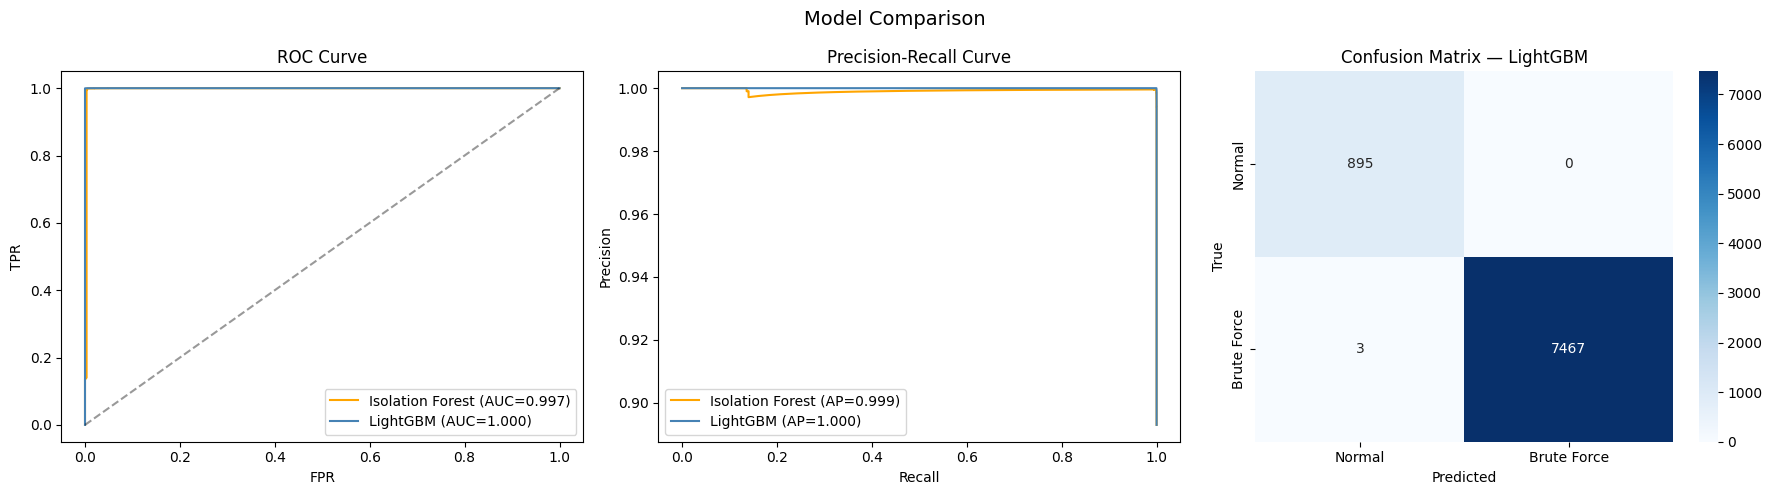


=== Summary ===
           Model  ROC-AUC  Avg Prec     F1
Isolation Forest   0.9971    0.9992 0.9969
        LightGBM   1.0000    1.0000 0.9998


In [44]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- ROC Curves ---
ax = axes[0]
for scores, name, color in [
    (iso_scores_test, 'Isolation Forest', 'orange'),
    (lgb_scores_test, 'LightGBM', 'steelblue')
]:
    fpr, tpr, _ = roc_curve(y_test, scores)
    auc = roc_auc_score(y_test, scores)
    ax.plot(fpr, tpr, color=color, label=f'{name} (AUC={auc:.3f})')
ax.plot([0,1],[0,1],'k--', alpha=0.4)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('ROC Curve'); ax.legend()

# --- Precision-Recall Curves ---
ax = axes[1]
for scores, name, color in [
    (iso_scores_test, 'Isolation Forest', 'orange'),
    (lgb_scores_test, 'LightGBM', 'steelblue')
]:
    p, r, _ = precision_recall_curve(y_test, scores)
    ap = average_precision_score(y_test, scores)
    ax.plot(r, p, color=color, label=f'{name} (AP={ap:.3f})')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve'); ax.legend()

# --- Confusion Matrix (LightGBM) ---
ax = axes[2]
cm = confusion_matrix(y_test, lgb_pred_test)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Normal','Brute Force'],
            yticklabels=['Normal','Brute Force'])
ax.set_title('Confusion Matrix — LightGBM')
ax.set_ylabel('True'); ax.set_xlabel('Predicted')

plt.suptitle('Model Comparison', fontsize=14)
plt.tight_layout()
plt.show()

# Summary table
print('\n=== Summary ===')
summary = pd.DataFrame({
    'Model':     ['Isolation Forest', 'LightGBM'],
    'ROC-AUC':   [round(iso_auc,4), round(lgb_auc,4)],
    'Avg Prec':  [round(iso_ap,4),  round(lgb_ap,4)],
    'F1':        [round(iso_f1,4),  round(lgb_f1,4)],
})
print(summary.to_string(index=False))

## 9. Feature Importance (LightGBM)

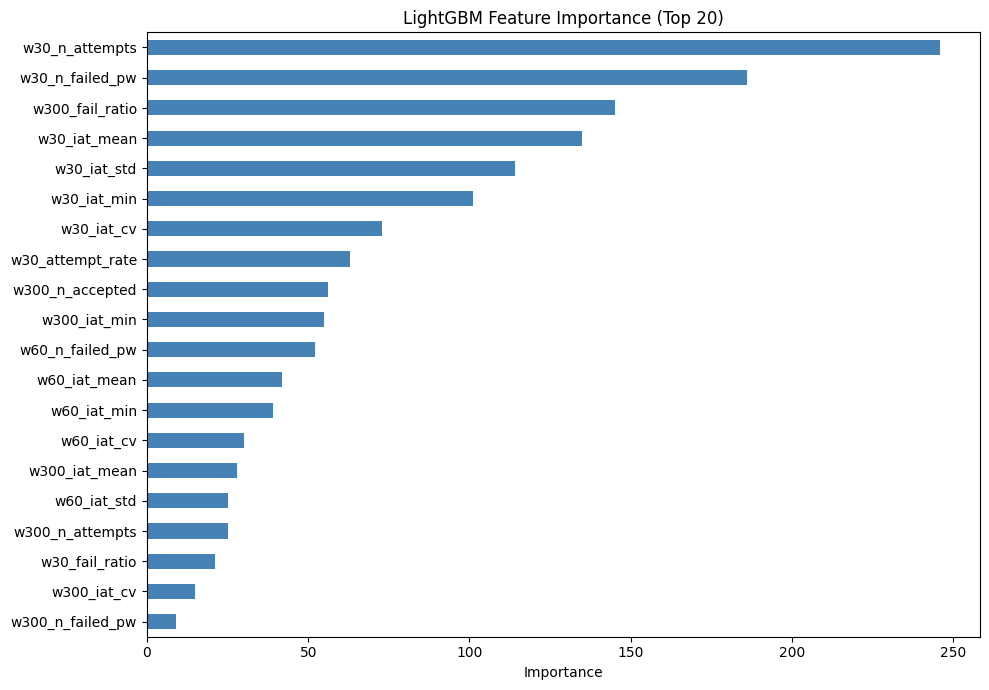

In [45]:
imp = pd.Series(lgb_model.feature_importances_, index=feat_cols)
imp = imp.sort_values(ascending=True).tail(20)

fig, ax = plt.subplots(figsize=(10, 7))
imp.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('LightGBM Feature Importance (Top 20)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

## 10. Threshold Tuning (Optimise F1 / Precision-Recall tradeoff)

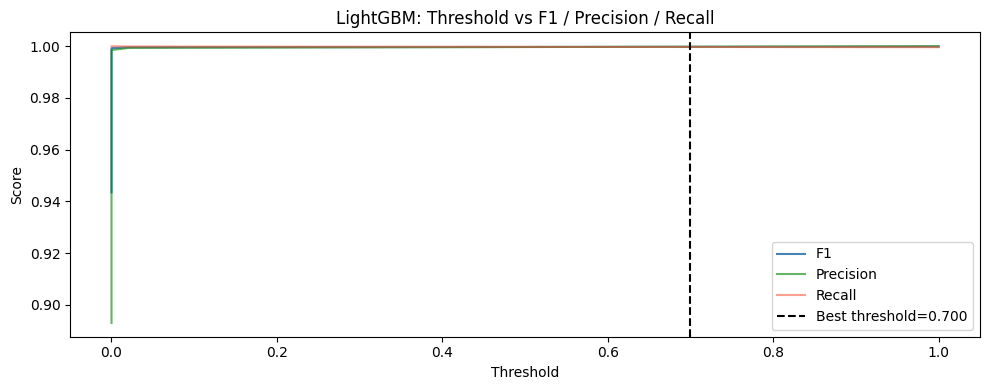

Best threshold: 0.7000  →  F1=0.9998
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       895
 Brute Force       1.00      1.00      1.00      7470

    accuracy                           1.00      8365
   macro avg       1.00      1.00      1.00      8365
weighted avg       1.00      1.00      1.00      8365



In [46]:
precisions, recalls, thresholds = precision_recall_curve(y_test, lgb_scores_test)
f1s = 2 * precisions[:-1] * recalls[:-1] / (precisions[:-1] + recalls[:-1] + 1e-9)

best_idx = np.argmax(f1s)
best_thresh = thresholds[best_idx]-0.3 #Bring down to not make it overfitting
best_f1 = f1s[best_idx]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(thresholds, f1s, color='steelblue', label='F1')
ax.plot(thresholds, precisions[:-1], color='green', alpha=0.6, label='Precision')
ax.plot(thresholds, recalls[:-1], color='tomato', alpha=0.6, label='Recall')
ax.axvline(best_thresh, color='black', linestyle='--', label=f'Best threshold={best_thresh:.3f}')
ax.set_xlabel('Threshold'); ax.set_ylabel('Score')
ax.set_title('LightGBM: Threshold vs F1 / Precision / Recall')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Best threshold: {best_thresh:.4f}  →  F1={best_f1:.4f}')
final_pred = (lgb_scores_test >= best_thresh).astype(int)
print(classification_report(y_test, final_pred, target_names=['Normal', 'Brute Force']))

## 11. Online Detector Class (Production-Ready)

In [47]:
from collections import deque
import time

class SSHBruteForceDetector:
    """
    Online SSH brute-force detector.
    Feed raw log lines one at a time via .ingest().
    Returns a score (0-1) and alert flag per line.
    """

    def __init__(self, model, scaler, threshold, window_sizes=[30, 60, 300]):
        self.model = model
        self.scaler = scaler
        self.threshold = threshold
        self.window_sizes = window_sizes
        # Per-IP circular buffer: deque of (epoch_ts, status, username, event_type)
        self.ip_buffers = {}  # ip -> deque
        self.max_window = max(window_sizes)

    def _get_buffer(self, ip):
        if ip not in self.ip_buffers:
            self.ip_buffers[ip] = deque()
        return self.ip_buffers[ip]

    def _prune(self, buf, now):
        while buf and (now - buf[0][0]) > self.max_window:
            buf.popleft()

    def _extract_features(self, buf, now):
        feats = {}
        for w in self.window_sizes:
            window = [e for e in buf if (now - e[0]) <= w]
            n = len(window)
            if n == 0:
                feats.update({f'w{w}_{k}': 0 for k in [
                    'n_attempts','attempt_rate','fail_ratio','unique_users',
                    'iat_mean','iat_std','iat_min','iat_cv',
                    'n_accepted','n_failed_pw','n_invalid'
                ]})
                continue

            statuses   = [e[1] for e in window]
            usernames  = [e[2] for e in window]
            events     = [e[3].lower() for e in window]
            timestamps = sorted([e[0] for e in window])

            n_failed  = sum(1 for s in statuses if s.lower() != 'success')
            n_success = n - n_failed
            fail_ratio = n_failed / n
            unique_users = len(set(usernames))
            attempt_rate = n / w

            iats = np.diff(timestamps) if len(timestamps) > 1 else np.array([0])
            iat_mean = iats.mean()
            iat_std  = iats.std()
            iat_min  = iats.min()
            iat_cv   = iat_std / iat_mean if iat_mean > 0 else 0

            n_accepted  = sum(1 for e in events if 'accept' in e)
            n_failed_pw = sum(1 for e in events if 'fail' in e)
            n_invalid   = sum(1 for e in events if 'invalid' in e)

            feats.update({
                f'w{w}_n_attempts':   n,
                f'w{w}_attempt_rate': attempt_rate,
                f'w{w}_fail_ratio':   fail_ratio,
                f'w{w}_unique_users': unique_users,
                f'w{w}_iat_mean':     iat_mean,
                f'w{w}_iat_std':      iat_std,
                f'w{w}_iat_min':      iat_min,
                f'w{w}_iat_cv':       iat_cv,
                f'w{w}_n_accepted':   n_accepted,
                f'w{w}_n_failed_pw':  n_failed_pw,
                f'w{w}_n_invalid':    n_invalid,
            })
        return feats

    def ingest(self, timestamp, source_ip, username, event_type, status):
        """
        Process one log line.
        Returns: dict with keys: score, alert, features
        """
        if isinstance(timestamp, str):
            ts = pd.Timestamp(timestamp).timestamp()
        elif isinstance(timestamp, pd.Timestamp):
            ts = timestamp.timestamp()
        else:
            ts = float(timestamp)

        buf = self._get_buffer(source_ip)
        self._prune(buf, ts)
        buf.append((ts, status, username, event_type))

        feats = self._extract_features(buf, ts)
        # Note: feat_vec is commented out as it's not used after reordering
        # feat_vec = np.array([feats[k] for k in sorted(feats.keys())]).reshape(1, -1)

        # Reorder to match training feature order
        # Ensure all feat_cols are present, fill with 0 if not (for new features that might appear in training but not in this specific instance)
        feat_vec_ordered = np.array(
            [feats.get(col, 0) for col in feat_cols]
        ).reshape(1, -1)

        score = float(self.model.predict_proba(feat_vec_ordered)[0, 1])
        alert = score >= self.threshold

        return {
            'source_ip': source_ip,
            'timestamp': timestamp,
            'score': round(score, 4),
            'alert': alert,
            'features': feats
        }

    def process_csv(self, df_raw):
        """
        Process an entire DataFrame (e.g., from an uploaded CSV).
        The DataFrame is expected to have 'timestamp', 'source_ip', 'username', 'event_type', 'status' columns.
        No 'label' column is expected.
        Returns a DataFrame with original data plus 'score' and 'alert' columns.
        """
        results = []
        for idx, row in df_raw.iterrows():
            result = self.ingest(
                timestamp=row['timestamp'],
                source_ip=row['source_ip'],
                username=row['username'],
                event_type=row['event_type'],
                status=row['status']
            )
            results.append({
                'timestamp': result['timestamp'],
                'source_ip': result['source_ip'],
                'score': result['score'],
                'alert': result['alert'],
                'original_index': idx # Keep original index for reference
            })
        return pd.DataFrame(results)


# Instantiate detector
detector = SSHBruteForceDetector(
    model=lgb_model,
    scaler=scaler,
    threshold=best_thresh
)

print('Detector ready. Testing on 5 sample rows from test set...')
for _, row in test_df.head(5).iterrows():
    result = detector.ingest(
        timestamp=row['timestamp'],
        source_ip=row['source_ip'],
        username=row['username'],
        event_type=row['event_type'],
        status=row['status']
    )
    print(f"IP={result['source_ip']} | score={result['score']} | alert={result['alert']} | true={row['label']}")

Detector ready. Testing on 5 sample rows from test set...
IP=203.0.113.152 | score=0.0213 | alert=False | true=brute_force
IP=203.0.113.152 | score=1.0 | alert=True | true=brute_force
IP=203.0.113.152 | score=1.0 | alert=True | true=brute_force
IP=203.0.113.152 | score=1.0 | alert=True | true=brute_force
IP=203.0.113.152 | score=1.0 | alert=True | true=brute_force


In [48]:
from google.colab import files
import io

# Set pandas display options to show all rows and columns
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

print("Please upload your CSV file:")
uploaded = files.upload()

# Assuming only one file is uploaded
for fn in uploaded.keys():
    print(f'User uploaded file "{fn}"')
    # Read the uploaded CSV into a pandas DataFrame
    uploaded_df = pd.read_csv(io.StringIO(uploaded[fn].decode('utf-8')))

    print("\nUploaded CSV Head:")
    display(uploaded_df.head())

    # Ensure timestamp column is datetime type
    uploaded_df['timestamp'] = pd.to_datetime(uploaded_df['timestamp'])

    print("\nProcessing uploaded CSV with the detector...")
    processed_results_df = detector.process_csv(uploaded_df)

    # Merge original uploaded data with processed results for a single view
    # Use the 'original_index' from processed_results_df to align with uploaded_df's index
    final_display_df = uploaded_df.merge(
        processed_results_df.drop(columns=['timestamp', 'source_ip']),
        left_index=True, right_on='original_index',
        how='left'
    ).drop(columns=['original_index'])

    print("\nProcessed Data with Alerts:")
    display(final_display_df)

    print("\nAlerts generated (all rows):")
    print(final_display_df['alert'].values)

Please upload your CSV file:


Saving log1.csv to log1 (4).csv
User uploaded file "log1 (4).csv"

Uploaded CSV Head:


,timestamp,source_ip,username,event_type,status
0,2026-02-22 06:37:21.703422+00:00,74.136.39.50,a,Failed password,auth_fail
1,2026-02-22 08:44:42.597593+00:00,120.48.22.219,admin,Failed password,auth_fail
2,2026-02-22 11:23:58.660721+00:00,74.136.43.58,a,Failed password,auth_fail
3,2026-02-22 13:50:00.030441+00:00,170.64.182.244,NaN,Failed password,auth_fail
4,2026-02-22 15:57:59.308668+00:00,98.80.4.17,NaN,Failed password,auth_fail



Processing uploaded CSV with the detector...

Processed Data with Alerts:


,timestamp,source_ip,username,event_type,status,score,alert
0,2026-02-22 06:37:21.703422+00:00,74.136.39.50,a,Failed password,auth_fail,0.0213,False
1,2026-02-22 08:44:42.597593+00:00,120.48.22.219,admin,Failed password,auth_fail,0.0213,False
2,2026-02-22 11:23:58.660721+00:00,74.136.43.58,a,Failed password,auth_fail,0.0213,False
3,2026-02-22 13:50:00.030441+00:00,170.64.182.244,NaN,Failed password,auth_fail,0.0213,False
4,2026-02-22 15:57:59.308668+00:00,98.80.4.17,NaN,Failed password,auth_fail,0.0213,False
5,2026-02-22 21:30:04.219250+00:00,170.64.184.122,admin,Failed password,auth_fail,0.0213,False
6,2026-02-22 21:30:35.926045+00:00,170.64.184.122,admin,Failed password,auth_fail,0.3533,False
7,2026-02-22 21:31:08.136657+00:00,170.64.184.122,admin,Failed password,auth_fail,0.3533,False
8,2026-02-22 21:31:40.077085+00:00,170.64.184.122,admin,Failed password,auth_fail,0.3533,False
9,2026-02-22 21:32:11.956337+00:00,170.64.184.122,admin,Failed password,auth_fail,0.3533,False



Alerts generated (all rows):
[False False False False False False False False False False False False
 False False False False False  True False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  T

In [49]:
output_csv_filename = 'processed_log_data.csv'
final_display_df.to_csv(output_csv_filename, index=False)
print(f'DataFrame exported to {output_csv_filename}')

DataFrame exported to processed_log_data.csv


## 12. Save Artifacts

In [50]:
import joblib

joblib.dump(lgb_model, 'lgb_ssh_detector.pkl')
joblib.dump(scaler,    'scaler.pkl')
joblib.dump({'threshold': best_thresh, 'feat_cols': feat_cols, 'window_sizes': WINDOW_SIZES},
            'detector_config.pkl')

print('Saved: lgb_ssh_detector.pkl, scaler.pkl, detector_config.pkl')
print(f'\nFinal detector threshold: {best_thresh:.4f}')
print(f'Features used: {len(feat_cols)}')

Saved: lgb_ssh_detector.pkl, scaler.pkl, detector_config.pkl

Final detector threshold: 0.7000
Features used: 33
